Solution Mapping:
 {'S': 9, 'E': 5, 'N': 6, 'D': 7, 'M': 1, 'O': 0, 'R': 8, 'Y': 2}

Formatted Output:

  9567
+ 1085
------
 10652

Steps explored: 2005572


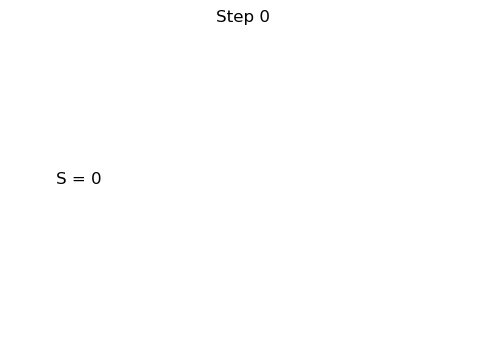

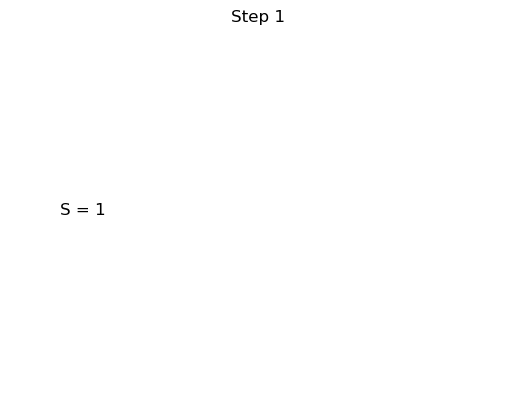

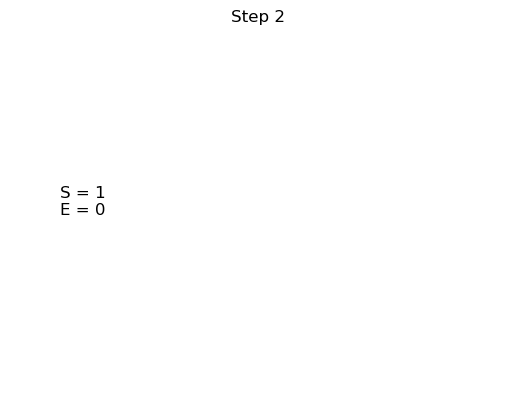

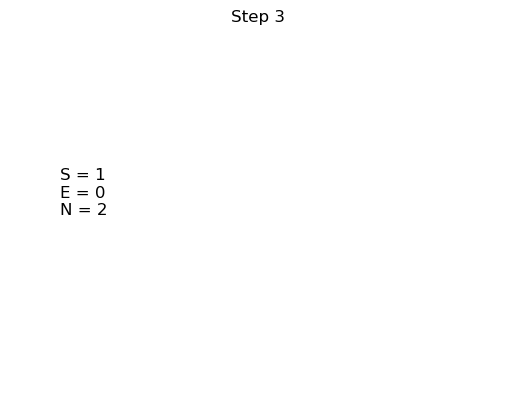

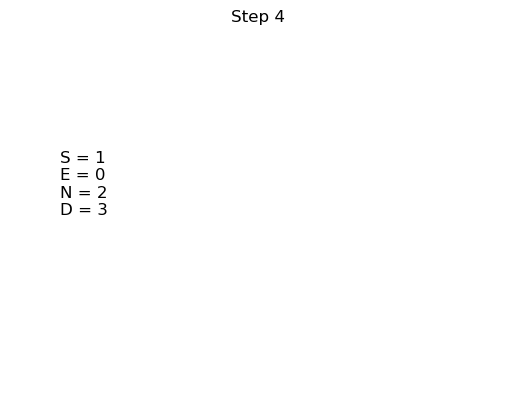

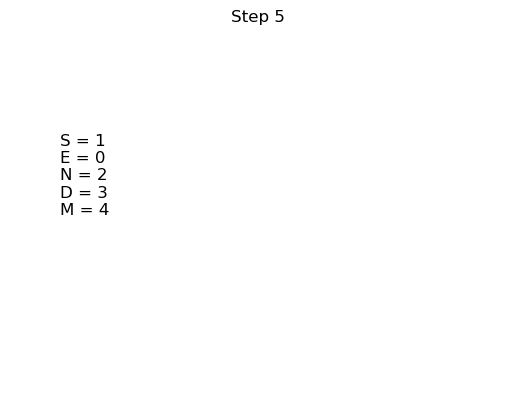

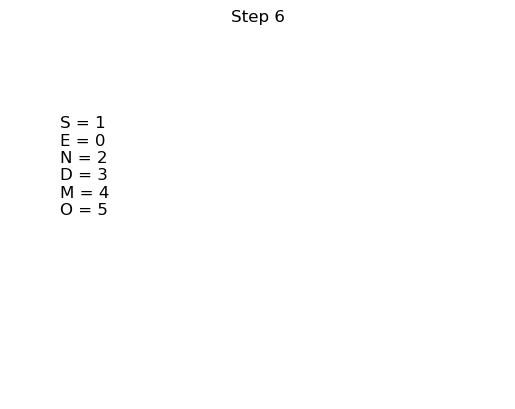

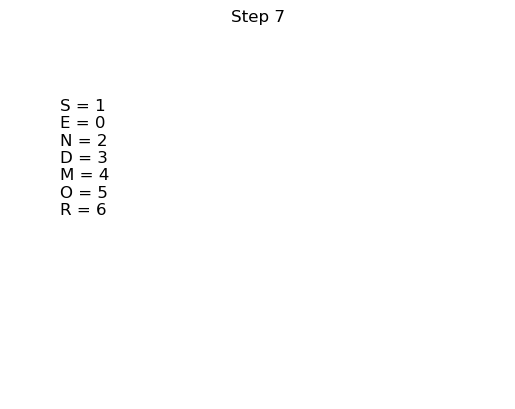

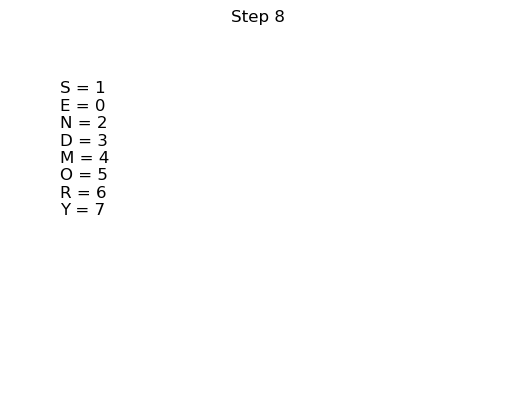

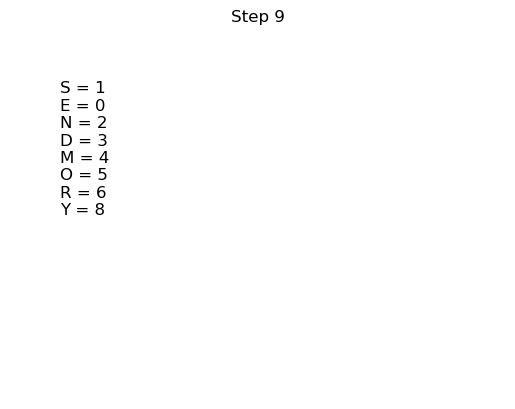

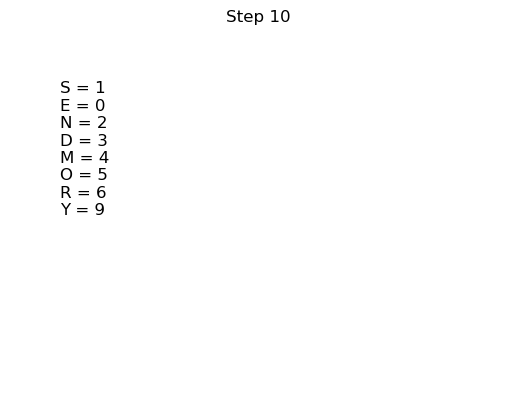

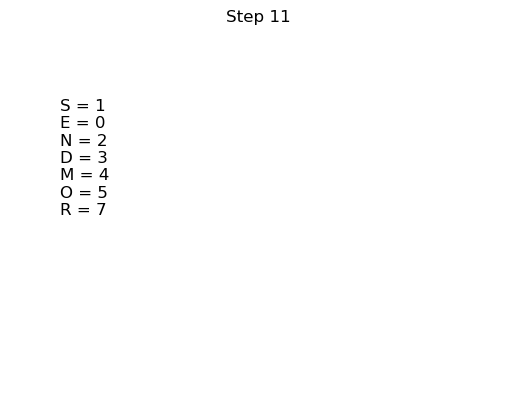

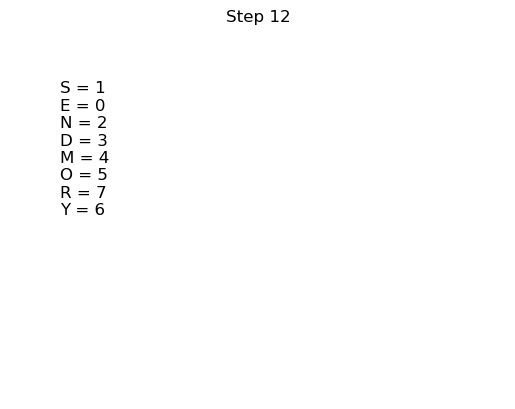

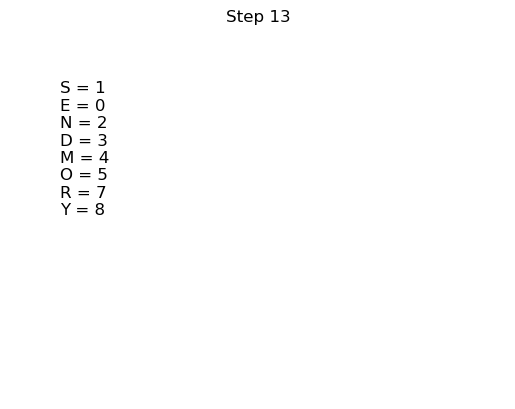

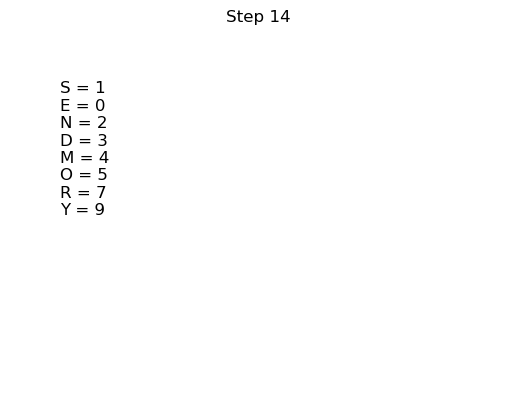

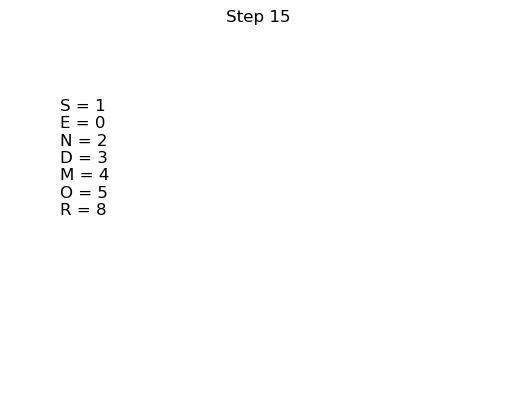

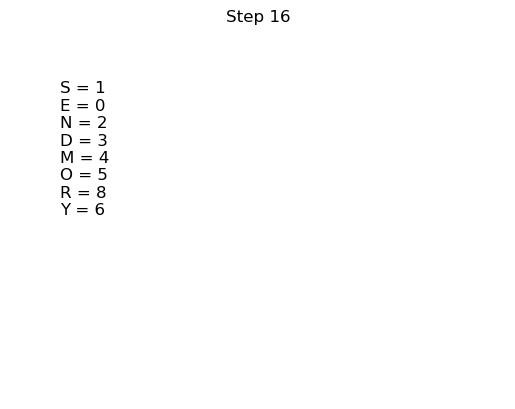

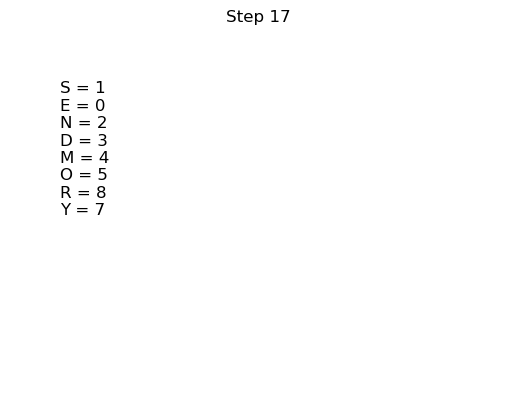

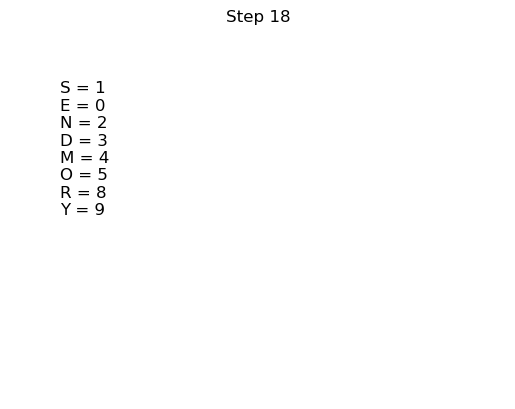

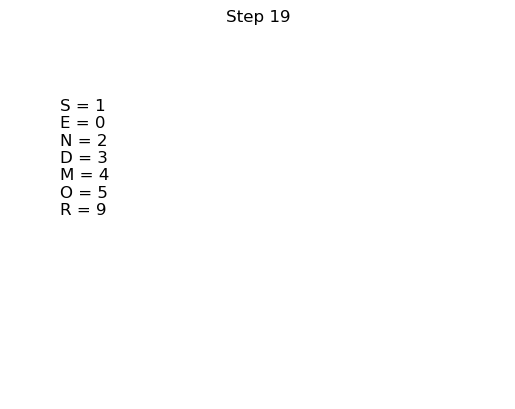

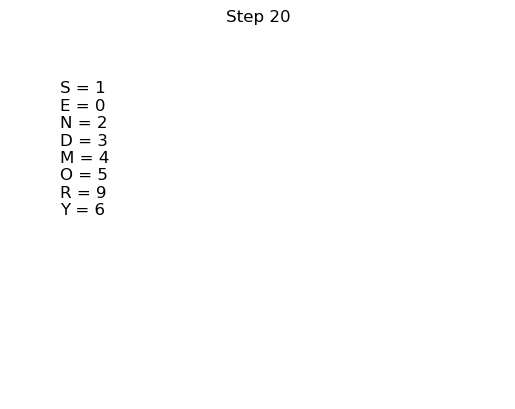

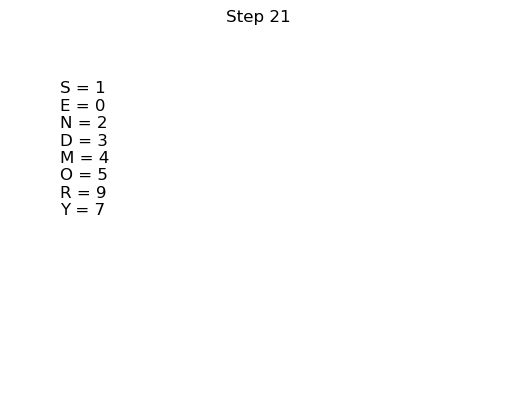

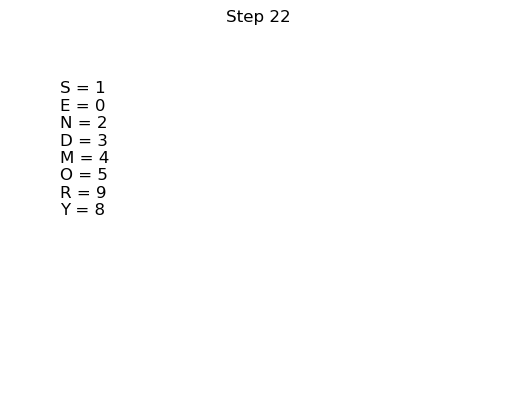

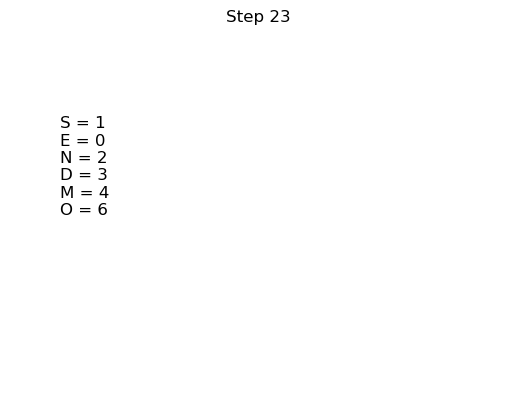

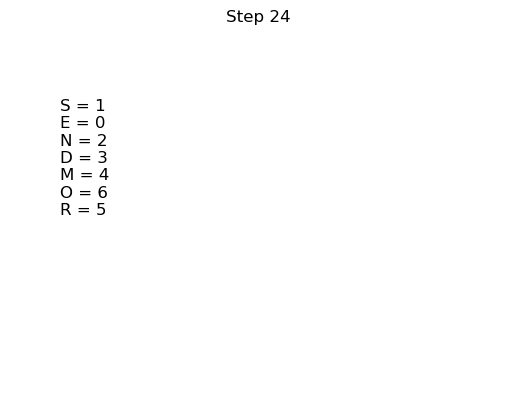

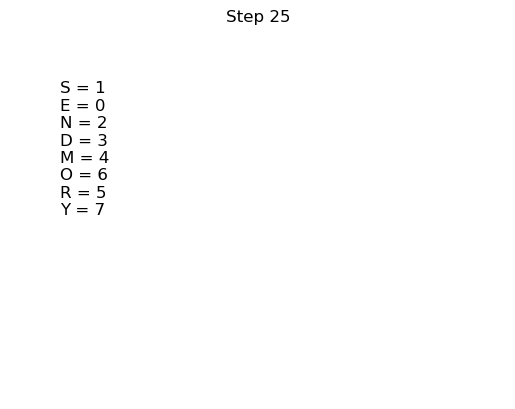

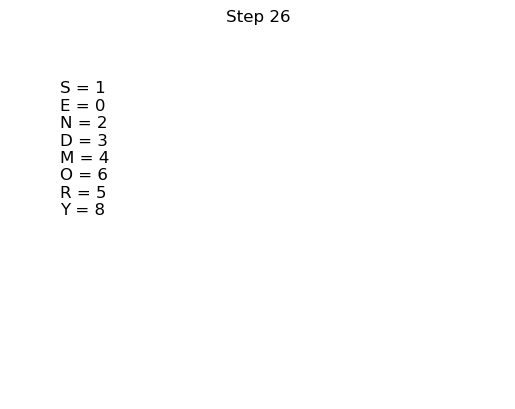

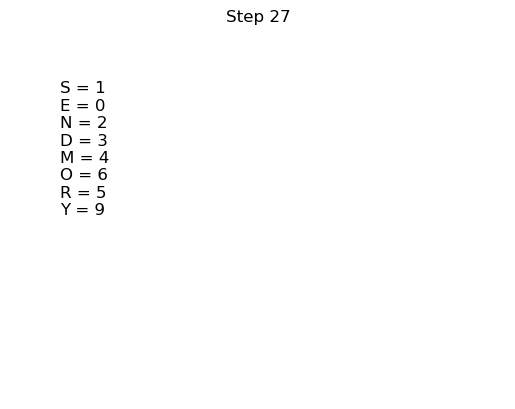

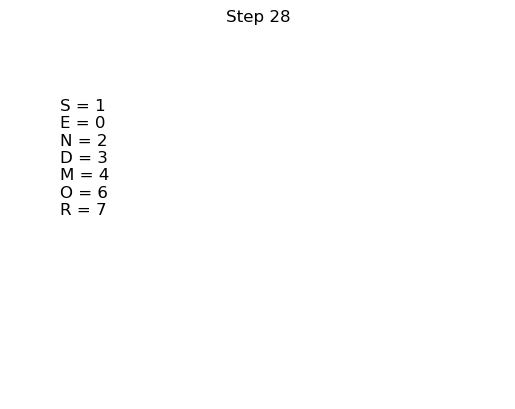

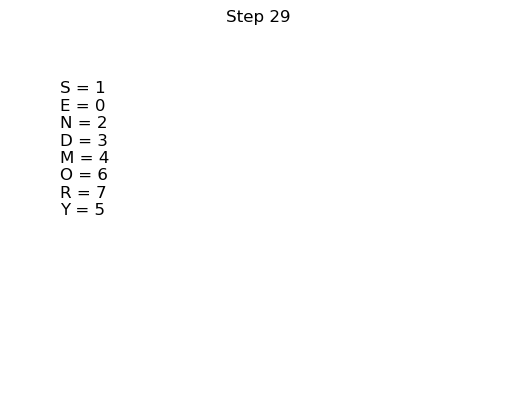

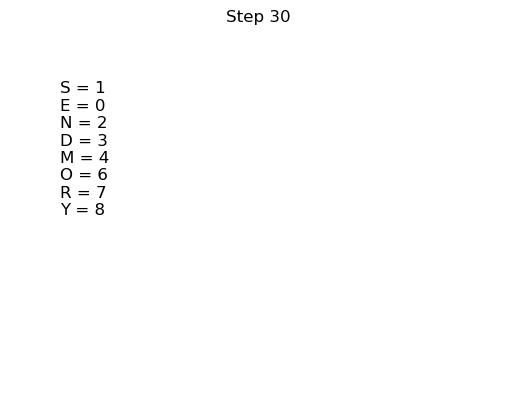

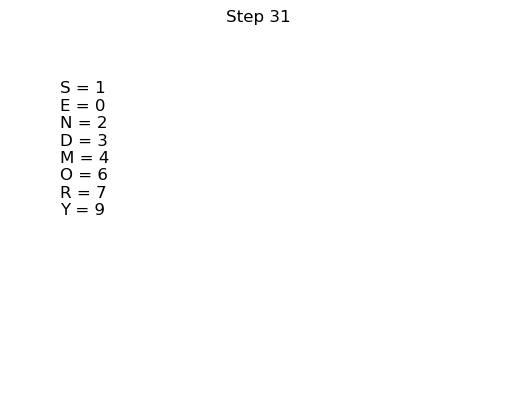

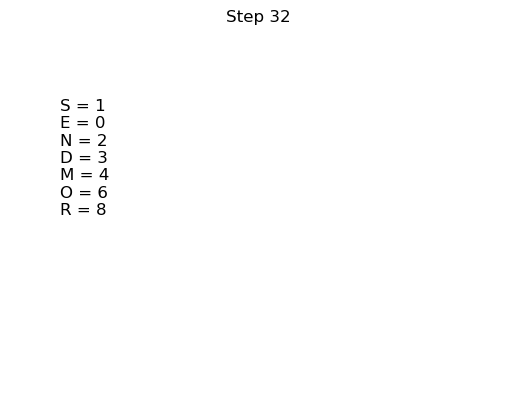

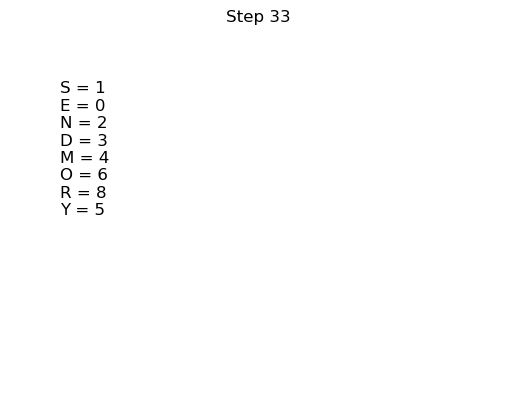

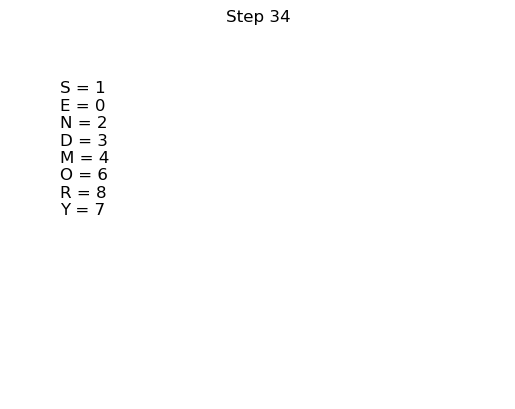

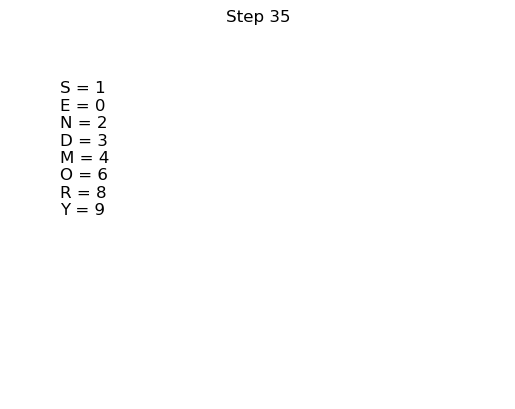

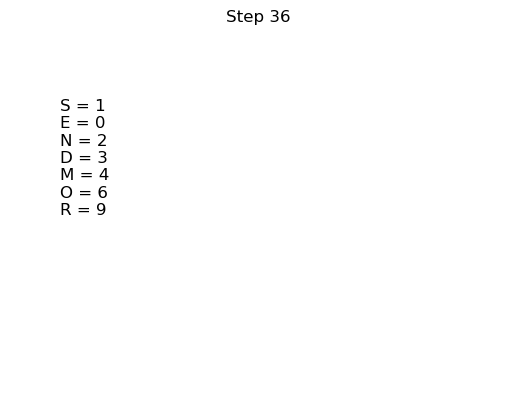

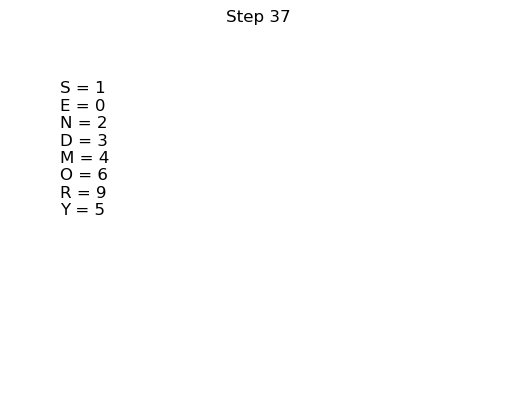

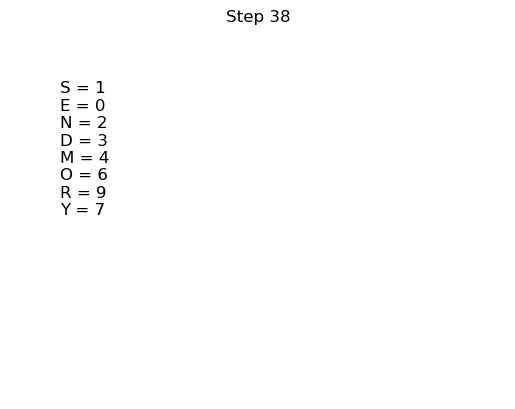

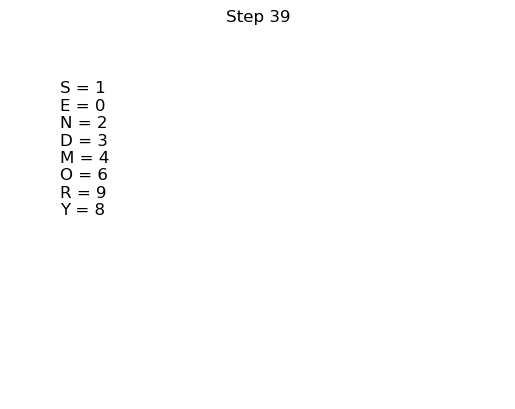

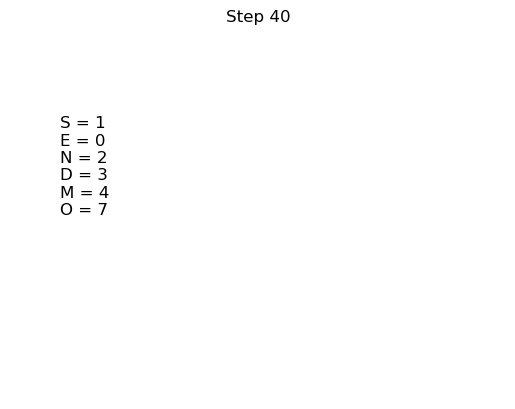

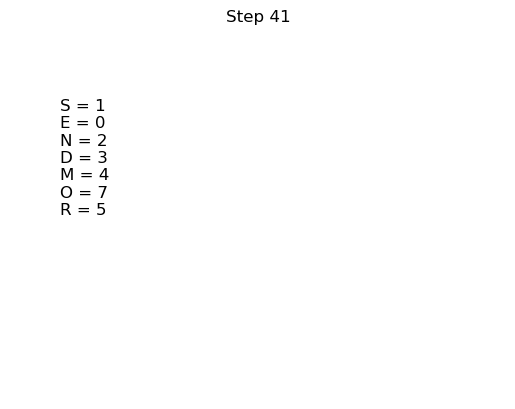

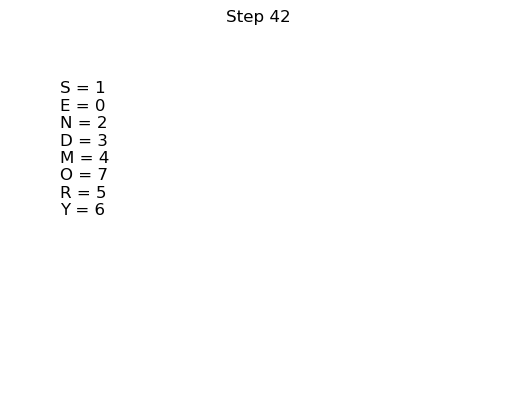

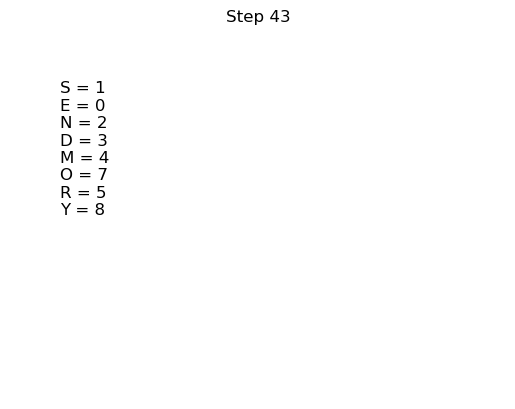

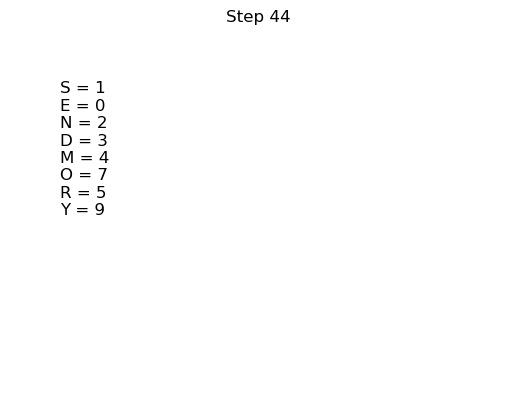

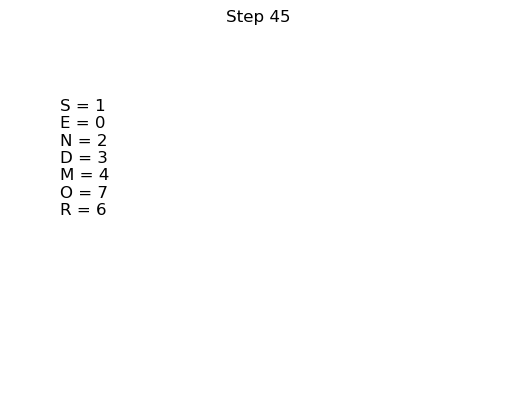

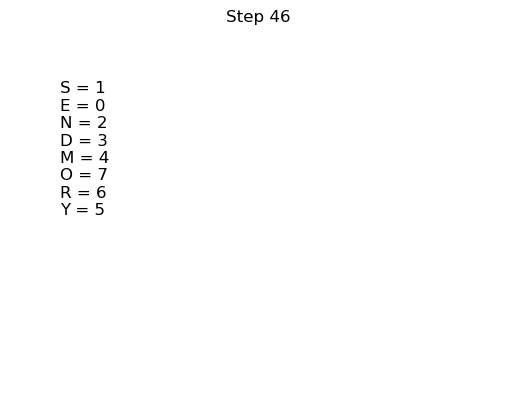

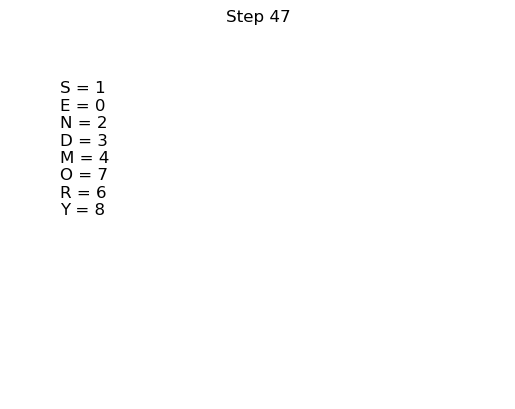

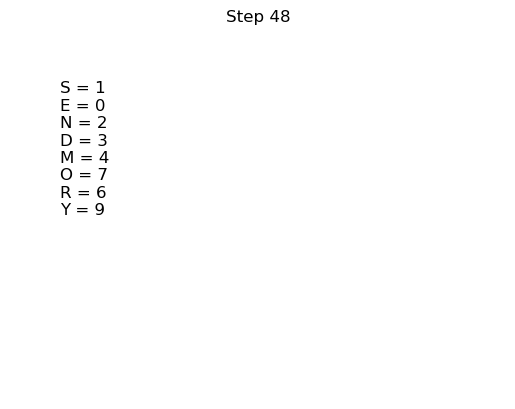

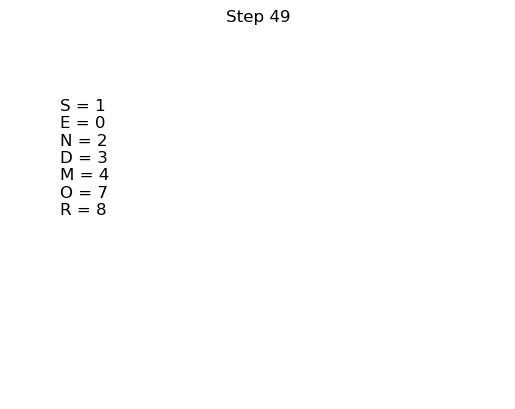

In [2]:
import matplotlib.pyplot as plt

class CryptCSP:
    def __init__(self):
        self.letters = ['S','E','N','D','M','O','R','Y']
        self.assignment = {}
        self.steps = []
        self.count = 0

    def is_valid(self):
        a = self.assignment

        # Leading zero constraint
        if 'S' in a and a['S'] == 0: return False
        if 'M' in a and a['M'] == 0: return False

        # If full assignment → check full equation
        if len(a) == 8:
            send = 1000*a['S'] + 100*a['E'] + 10*a['N'] + a['D']
            more = 1000*a['M'] + 100*a['O'] + 10*a['R'] + a['E']
            money = 10000*a['M'] + 1000*a['O'] + 100*a['N'] + 10*a['E'] + a['Y']
            return send + more == money

        return True

    def backtrack(self):
        if len(self.assignment) == len(self.letters):
            return True

        var = [l for l in self.letters if l not in self.assignment][0]

        for digit in range(10):
            if digit not in self.assignment.values():
                self.assignment[var] = digit
                self.count += 1
                self.steps.append(self.assignment.copy())

                if self.is_valid():
                    if self.backtrack():
                        return True

                del self.assignment[var]

        return False

    def visualize(self):
        plt.figure(figsize=(6,4))
        for i, step in enumerate(self.steps[:50]):
            plt.clf()
            text = "\n".join([f"{k} = {v}" for k,v in step.items()])
            plt.text(0.1, 0.5, text, fontsize=12)
            plt.title(f"Step {i}")
            plt.axis('off')
            plt.pause(0.2)
        plt.show()


solver = CryptCSP()
found = solver.backtrack()

if found:
    a = solver.assignment

    send = 1000*a['S'] + 100*a['E'] + 10*a['N'] + a['D']
    more = 1000*a['M'] + 100*a['O'] + 10*a['R'] + a['E']
    money = 10000*a['M'] + 1000*a['O'] + 100*a['N'] + 10*a['E'] + a['Y']

    print("Solution Mapping:\n", a)

    print("\nFormatted Output:\n")
    print(f"  {send}")
    print(f"+ {more}")
    print("------")
    print(f" {money}")

    print("\nSteps explored:", solver.count)

    solver.visualize()

else:
    print("No solution found")